####  Imports & Setup

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')
DATA_PATH = 'D:/D2C Customer Churn Intelligence & Retention API/d2c-churn-eda-audit/data/raw'  # Path to your CSV files

print("Libraries loaded.")

Libraries loaded.


####  Data Loading

In [15]:
# Load Datasets (Adjust filenames to match your specific download)
try:
    customers = pd.read_csv(os.path.join(DATA_PATH, 'customers.csv'))
    orders = pd.read_csv(os.path.join(DATA_PATH, 'orders.csv'))
    support = pd.read_csv(os.path.join(DATA_PATH, 'support_tickets.csv'))
    churn = pd.read_csv(os.path.join(DATA_PATH, 'churn_labels.csv'))
    intervention = pd.read_csv(os.path.join(DATA_PATH, 'intervention_history.csv'))
    web_events = pd.read_csv(os.path.join(DATA_PATH, 'web_events_snapshot.csv'))
    
    print("Data loaded successfully.")
    print(f"Customers: {customers.shape}")
    print(f"Orders: {orders.shape}")
    print(f"Support Tickets: {support.shape}")
    print(f"Churn Labels: {churn.shape}")
    print(f"Intervention History: {intervention.shape}")
    print(f"Web Events: {web_events.shape}")
except FileNotFoundError as e:
    print(f"Error loading files: {e}. Please check filenames in your /data folder.")


Data loaded successfully.
Customers: (2400, 9)
Orders: (10009, 10)
Support Tickets: (1921, 8)
Churn Labels: (2400, 4)
Intervention History: (2400, 5)
Web Events: (2400, 10)


#### Data Quality Audit (Missing & Duplicates)

In [20]:
def audit_dataframe(df, name):
    print(f"--- Audit: {name} ---")
    print("Data Types:")
    print(df.dtypes)
    print(f"Duplicates: {df.duplicated().sum()}")
    print("Missing Values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print("\n")

audit_dataframe(customers, "Customers")
audit_dataframe(orders, "Orders")
audit_dataframe(support, "Support")
audit_dataframe(churn, "Churn Labels")
audit_dataframe(intervention, "Intervention History")
audit_dataframe(web_events, "Web Events")

--- Audit: Customers ---
Data Types:
customer_id            object
signup_date            object
city_tier              object
age_group              object
acquisition_channel    object
loyalty_tier           object
preferred_category     object
skin_type              object
marketing_consent      object
dtype: object
Duplicates: 0
Missing Values:
loyalty_tier    1386
skin_type        401
dtype: int64


--- Audit: Orders ---
Data Types:
order_id          object
customer_id       object
order_date        object
category          object
quantity           int64
gross_amount     float64
discount_pct     float64
delivery_days      int64
returned           int64
rating           float64
dtype: object
Duplicates: 0
Missing Values:
rating    80
dtype: int64


--- Audit: Support ---
Data Types:
ticket_id            object
customer_id          object
ticket_date          object
issue_type           object
support_channel      object
resolution_hours    float64
sentiment_score     float64
reope

In [22]:
# Step 1: Ensure dates are processed correctly
orders['order_date'] = pd.to_datetime(orders['order_date'])
churn['snapshot_date'] = pd.to_datetime(churn['snapshot_date'])

# Step 2: Extract key information from the Orders table per customer
# We calculate total gross amount, total discount percentage, average rating, and return count
customer_orders = orders.groupby('customer_id').agg(
    total_orders=('order_id', 'count'),
    total_gross_spent=('gross_amount', 'sum'),
    average_discount=('discount_pct', 'mean'),
    average_delivery_days=('delivery_days', 'mean'),
    total_returned_items=('returned', 'sum'),
    average_order_rating=('rating', 'mean')
).reset_index()

# Step 3: Extract key information from the Support table per customer
customer_support = support.groupby('customer_id').agg(
    total_tickets=('ticket_id', 'count'),
    average_resolution_hours=('resolution_hours', 'mean'),
    average_sentiment_score=('sentiment_score', 'mean'),
    total_reopened_tickets=('reopened', 'sum')
).reset_index()

# Step 4: Combine everything into our Analysis Dataset using Churn Labels as the base table
master_data = pd.merge(churn, customers, on='customer_id', how='left')
master_data = pd.merge(master_data, customer_orders, on='customer_id', how='left')
master_data = pd.merge(master_data, customer_support, on='customer_id', how='left')
master_data = pd.merge(master_data, web_events, on='customer_id', how='left')
master_data = pd.merge(master_data, intervention, on='customer_id', how='left')

# Step 5: Fill in empty gaps for customers with no orders or support tickets
master_data['total_orders'] = master_data['total_orders'].fillna(0)
master_data['total_gross_spent'] = master_data['total_gross_spent'].fillna(0)
master_data['average_discount'] = master_data['average_discount'].fillna(0)
master_data['total_returned_items'] = master_data['total_returned_items'].fillna(0)
master_data['total_tickets'] = master_data['total_tickets'].fillna(0)
master_data['total_reopened_tickets'] = master_data['total_reopened_tickets'].fillna(0)

# Replace missing average sentiment with 0 (neutral) and resolution hours with 0
master_data['average_sentiment_score'] = master_data['average_sentiment_score'].fillna(0)
master_data['average_resolution_hours'] = master_data['average_resolution_hours'].fillna(0)

print("--- Master Dataset Compiled Successfully ---")
print(f"Master Shape: {master_data.shape}")

# Step 6: Print foundational behavioral comparisons grouped by our target label (churn_next_60d)
print("\n--- Summary Averages: Retained (0) vs Churned (1) ---")
summary_cols = [
    'total_orders', 'total_gross_spent', 'total_tickets', 
    'sessions_30d', 'last_visit_days_ago', 'average_sentiment_score'
]
print(master_data.groupby('churn_next_60d')[summary_cols].mean())



--- Master Dataset Compiled Successfully ---
Master Shape: (2400, 35)

--- Summary Averages: Retained (0) vs Churned (1) ---
                total_orders  total_gross_spent  total_tickets  sessions_30d  \
churn_next_60d                                                                 
0                   5.175177        3881.434564       0.852317      6.732129   
1                   3.035492        2222.372609       0.741792      4.023070   

                last_visit_days_ago  average_sentiment_score  
churn_next_60d                                                
0                          9.771406                -0.223016  
1                         26.554570                -0.227364  


In [23]:
# a small helper function to easily view churn rates across different groups
def check_churn_rate(column_name):
    print(f"\n--- Churn Rate by {column_name} ---")
    # Calculate the percentage of people who churn in each group
    summary = master_data.groupby(column_name)['churn_next_60d'].agg(
        total_customers='count',
        churn_percentage=lambda x: round(x.mean() * 100, 2)
    )
    print(summary)

# 1. Check if the acquisition channel alters churn risk
check_churn_rate('acquisition_channel')

# 2. Check if specific product interests cause higher churn
check_churn_rate('preferred_category')

# 3. Check if age groups behave differently
check_churn_rate('age_group')

# 4. Check if missing profiles play a major role
# We temporarily fill missing values with text to evaluate them clearly
master_data['loyalty_tier_clean'] = master_data['loyalty_tier'].fillna('Missing_Tier')
check_churn_rate('loyalty_tier_clean')



--- Churn Rate by acquisition_channel ---
                     total_customers  churn_percentage
acquisition_channel                                   
Google Search                    466             50.43
Influencer                       231             47.62
Instagram                        517             49.90
Marketplace                      456             49.12
Organic                          334             39.82
Referral                         396             42.17

--- Churn Rate by preferred_category ---
                    total_customers  churn_percentage
preferred_category                                   
Baby Care                       347             50.72
Fragrance                       238             45.38
Hair Care                       507             45.17
Makeup                          326             45.40
Skin Care                       731             47.20
Wellness                        251             48.21

--- Churn Rate by age_group ---
          

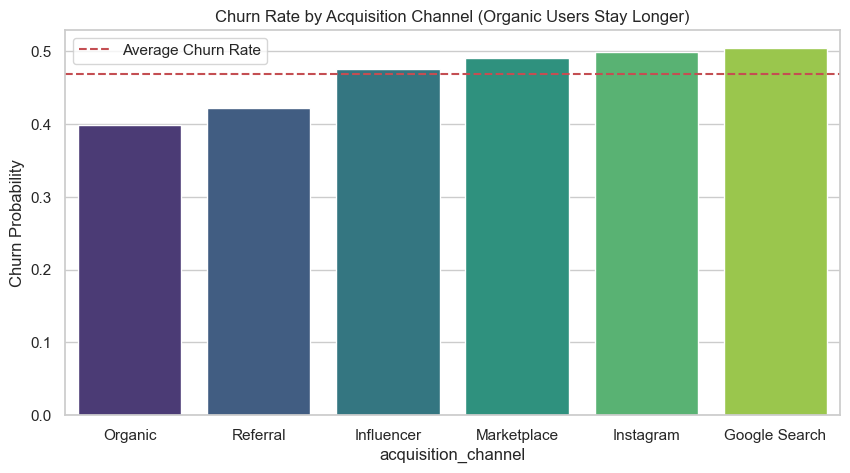

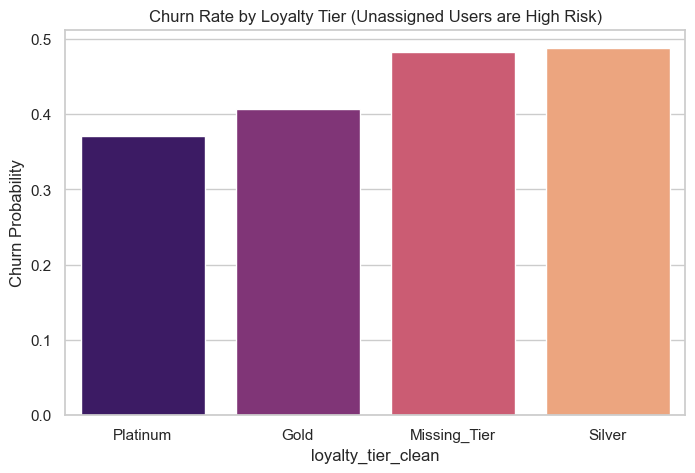

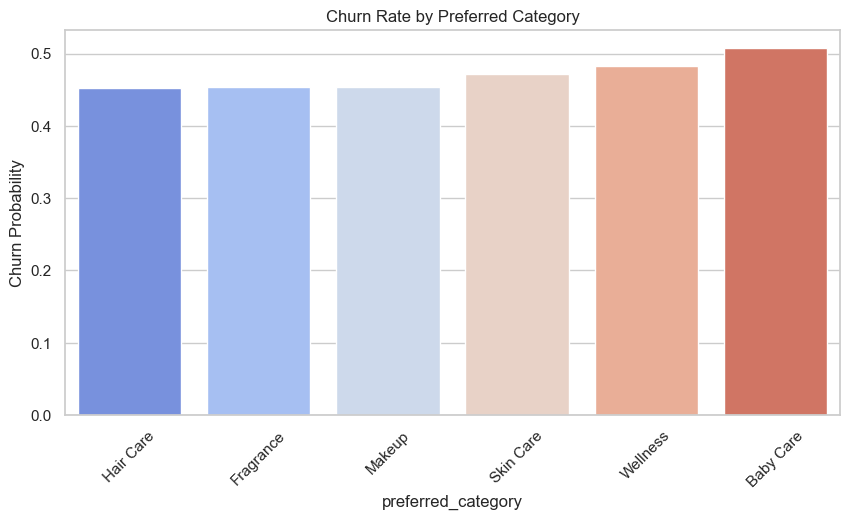

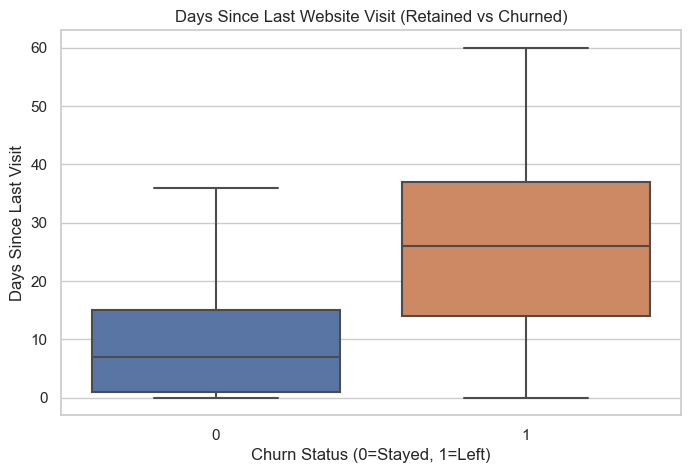

In [24]:
# Set up the visual style
sns.set(style="whitegrid")

# Chart 4: Churn Rate by Acquisition Channel
# (Evidence: Google/Instagram users churn much faster than Organic ones)
plt.figure(figsize=(10, 5))
channel_churn = master_data.groupby('acquisition_channel')['churn_next_60d'].mean().sort_values()
sns.barplot(x=channel_churn.index, y=channel_churn.values, palette="viridis")
plt.title("Churn Rate by Acquisition Channel (Organic Users Stay Longer)")
plt.ylabel("Churn Probability")
plt.axhline(y=master_data['churn_next_60d'].mean(), color='r', linestyle='--', label='Average Churn Rate')
plt.legend()
plt.show()

# Chart 5: The "Hidden" Risk of Missing Loyalty Tiers
# (Evidence: The 'Missing_Tier' group is nearly 50% likely to leave)
plt.figure(figsize=(8, 5))
tier_churn = master_data.groupby('loyalty_tier_clean')['churn_next_60d'].mean().sort_values()
sns.barplot(x=tier_churn.index, y=tier_churn.values, palette="magma")
plt.title("Churn Rate by Loyalty Tier (Unassigned Users are High Risk)")
plt.ylabel("Churn Probability")
plt.show()

# Chart 6: Product Category Risk
# (Evidence: Baby Care has the highest churn rate at 50.7%)
plt.figure(figsize=(10, 5))
cat_churn = master_data.groupby('preferred_category')['churn_next_60d'].mean().sort_values()
sns.barplot(x=cat_churn.index, y=cat_churn.values, palette="coolwarm")
plt.title("Churn Rate by Preferred Category")
plt.ylabel("Churn Probability")
plt.xticks(rotation=45)
plt.show()

# Chart 7: The "Ghost" Effect (Activity Recency)
# (Evidence: Churned users have a massive gap in activity)
plt.figure(figsize=(8, 5))
sns.boxplot(x='churn_next_60d', y='last_visit_days_ago', data=master_data, showfliers=False)
plt.title("Days Since Last Website Visit (Retained vs Churned)")
plt.xlabel("Churn Status (0=Stayed, 1=Left)")
plt.ylabel("Days Since Last Visit")
plt.show()
